In [35]:
!pip install yfinance pandas numpy matplotlib seaborn scipy


Portfolio Risk Analytics


In [1]:
"""
Portfolio Risk Analytics
Equal-weighted 15-stock portfolio across 5 sectors.
Computes: annualised return/vol/Sharpe, max drawdown,
correlation matrix, covariance-based risk decomposition.
Visualised in a 4-panel dashboard.



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import warnings
from datetime import date

warnings.filterwarnings("ignore")

# ── Portfolio Definition ─────────────────────────────────────────────────────

SECTORS = {
    "Technology":        ["AAPL", "MSFT", "NVDA", "AVGO", "ORCL"],
    "Financials":        ["JPM", "BAC", "GS", "MS", "V"],
    "Energy":            ["XOM", "CVX", "SLB", "COP", "EOG"],
    "Healthcare":        ["JNJ", "PFE", "UNH", "MRK", "ABT"],
    "Consumer Staples":  ["KO", "PG", "PEP", "WMT", "COST"],
}

TICKERS = [t for tickers in SECTORS.values() for t in tickers]
N = len(TICKERS)
WEIGHT = 1.0 / N                     
WEIGHTS = np.full(N, WEIGHT)

START = "2010-01-01"
END   = date.today().strftime("%Y-%m-%d")
RISK_FREE = 0.05                     # annualised risk-free rate (approx. 5 %)
TRADING_DAYS = 252

SECTOR_PALETTE = {
    "Technology":       "#4C72B0",
    "Financials":       "#55A868",
    "Energy":           "#C44E52",
    "Healthcare":       "#8172B2",
    "Consumer Staples": "#CCB974",
}

# ── Data Fetch ───────────────────────────────────────────────────────────────

def fetch_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    print(f"Fetching {len(tickers)} tickers from {start} to {end} …")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"][tickers].dropna()
    print(f"  {len(prices)} trading days loaded.\n")
    return prices

# ── Core Analytics ───────────────────────────────────────────────────────────

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()

def annualised_return(returns: pd.DataFrame, weights: np.ndarray) -> float:
    port_daily = returns @ weights
    return (1 + port_daily.mean()) ** TRADING_DAYS - 1

def annualised_volatility(returns: pd.DataFrame, weights: np.ndarray) -> float:
    cov = returns.cov() * TRADING_DAYS
    return float(np.sqrt(weights @ cov.values @ weights))

def sharpe_ratio(ann_ret: float, ann_vol: float) -> float:
    return (ann_ret - RISK_FREE) / ann_vol

def max_drawdown(prices: pd.DataFrame, weights: np.ndarray) -> tuple[float, pd.Series]:
    port_value = (prices / prices.iloc[0] * weights).sum(axis=1)
    rolling_max = port_value.cummax()
    drawdown = (port_value - rolling_max) / rolling_max
    return float(drawdown.min()), drawdown

def risk_decomposition(returns: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    """
    Marginal contribution to risk (MCR) × weight = component contribution to risk.
    Expressed as a fraction of total portfolio volatility.
    """
    cov = returns.cov() * TRADING_DAYS
    cov_arr = cov.values
    port_var = weights @ cov_arr @ weights
    port_vol = np.sqrt(port_var)

    marginal = cov_arr @ weights           # ∂σ/∂wᵢ (un-normalised)
    component = weights * marginal / port_vol   # contribution to vol
    pct_contribution = component / port_vol * 100

    return pd.Series(pct_contribution, index=returns.columns, name="Risk Contribution (%)")

# ── Plotting ─────────────────────────────────────────────────────────────────

def ticker_to_sector(ticker: str) -> str:
    for sector, tickers in SECTORS.items():
        if ticker in tickers:
            return sector
    return "Unknown"

def plot_dashboard(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    drawdown: pd.Series,
    risk_contrib: pd.Series,
    ann_ret: float,
    ann_vol: float,
    sharpe: float,
    mdd: float,
):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(20, 14), facecolor="#F7F7F7")
    fig.suptitle(
        "Portfolio Risk Analytics — Equal-Weighted 15-Stock, 5-Sector Portfolio",
        fontsize=16, fontweight="bold", y=0.98,
    )

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        left=0.07, right=0.97,
        top=0.93, bottom=0.07,
        hspace=0.38, wspace=0.32,
    )

    ax1 = fig.add_subplot(gs[0, 0])   # Panel 1 – Cumulative NAV + drawdown
    ax2 = fig.add_subplot(gs[0, 1])   # Panel 2 – Risk contribution bar
    ax3 = fig.add_subplot(gs[1, 0])   # Panel 3 – Correlation heat-map
    ax4 = fig.add_subplot(gs[1, 1])   # Panel 4 – Capital vs Risk weight

    # ── Panel 1: Portfolio NAV & Drawdown ──────────────────────────────────
    port_value = (prices / prices.iloc[0] * WEIGHT).sum(axis=1)
    ax1_dd = ax1.twinx()

    ax1_dd.fill_between(drawdown.index, drawdown * 100, 0,
                        color="#C44E52", alpha=0.20, label="Drawdown")
    ax1_dd.set_ylabel("Drawdown (%)", color="#C44E52", fontsize=9)
    ax1_dd.tick_params(axis="y", colors="#C44E52")
    ax1_dd.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    ax1.plot(port_value.index, port_value, color="#4C72B0", linewidth=1.8,
             label="Portfolio NAV")
    ax1.set_title("Cumulative Portfolio Value & Drawdown", fontsize=11, fontweight="bold")
    ax1.set_ylabel("NAV (base = 1.00)", fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    stats_text = (
        f"Ann. Return : {ann_ret*100:+.1f}%\n"
        f"Ann. Vol    : {ann_vol*100:.1f}%\n"
        f"Sharpe      : {sharpe:.2f}\n"
        f"Max Drawdown: {mdd*100:.1f}%"
    )
    ax1.text(
        0.02, 0.97, stats_text,
        transform=ax1.transAxes,
        fontsize=8.5, verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
    )
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_dd.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower right")

    # ── Panel 2: Risk Contribution ─────────────────────────────────────────
    rc_df = risk_contrib.reset_index()
    rc_df.columns = ["Ticker", "Risk (%)"]
    rc_df["Sector"] = rc_df["Ticker"].map(ticker_to_sector)
    rc_df = rc_df.sort_values("Risk (%)", ascending=True)

    colors = [SECTOR_PALETTE[s] for s in rc_df["Sector"]]
    bars = ax2.barh(rc_df["Ticker"], rc_df["Risk (%)"], color=colors, edgecolor="white")
    ax2.axvline(WEIGHT * 100, color="black", linestyle="--", linewidth=1.2,
                label=f"Equal capital weight ({WEIGHT*100:.2f}%)")

    for bar, val in zip(bars, rc_df["Risk (%)"]):
        ax2.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=7.5)

    ax2.set_title("Covariance-Based Risk Contribution per Stock", fontsize=11, fontweight="bold")
    ax2.set_xlabel("% of Total Portfolio Volatility")
    ax2.legend(fontsize=8)

    # sector legend patches
    from matplotlib.patches import Patch
    sector_patches = [Patch(color=c, label=s) for s, c in SECTOR_PALETTE.items()]
    ax2.legend(
        handles=sector_patches + [plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                                             label=f"Equal capital weight ({WEIGHT*100:.2f}%)")],
        fontsize=7.5, loc="lower right",
    )

    # ── Panel 3: Correlation Heat-map ──────────────────────────────────────
    corr = returns.corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(
        corr, ax=ax3,
        cmap="RdYlGn_r",
        vmin=-1, vmax=1,
        linewidths=0.4,
        annot=True, fmt=".2f", annot_kws={"size": 6.5},
        cbar_kws={"shrink": 0.8, "label": "Pearson ρ"},
        square=True,
    )
    ax3.set_title("Pairwise Correlation Matrix", fontsize=11, fontweight="bold")
    ax3.tick_params(axis="x", labelsize=7.5, rotation=45)
    ax3.tick_params(axis="y", labelsize=7.5, rotation=0)

    # ── Panel 4: Capital Weight vs Risk Weight ─────────────────────────────
    risk_weight = risk_contrib / risk_contrib.sum() * 100  # normalise to 100 %
    cap_weight  = pd.Series(WEIGHT * 100, index=TICKERS)

    tickers_sorted = risk_weight.sort_values(ascending=False).index.tolist()
    x = np.arange(len(tickers_sorted))
    width = 0.38

    cap_vals  = [cap_weight[t]  for t in tickers_sorted]
    risk_vals = [risk_weight[t] for t in tickers_sorted]
    bar_colors = [SECTOR_PALETTE[ticker_to_sector(t)] for t in tickers_sorted]

    ax4.bar(x - width / 2, cap_vals,  width, label="Capital weight (%)",
            color="steelblue", alpha=0.75, edgecolor="white")
    ax4.bar(x + width / 2, risk_vals, width, label="Risk weight (%)",
            color=bar_colors, alpha=0.90, edgecolor="white")

    ax4.set_xticks(x)
    ax4.set_xticklabels(tickers_sorted, rotation=45, ha="right", fontsize=8)
    ax4.set_ylabel("Weight (%)")
    ax4.set_title("Capital Weight vs Normalised Risk Weight", fontsize=11, fontweight="bold")
    ax4.legend(fontsize=8)
    ax4.axhline(WEIGHT * 100, color="gray", linestyle=":", linewidth=1)

    plt.savefig("portfolio_risk_dashboard.png", dpi=150, bbox_inches="tight")
    print("Dashboard saved → portfolio_risk_dashboard.png")
    plt.show()

# ── Main ─────────────────────────────────────────────────────────────────────

def main():
    # 1. Data
    prices  = fetch_prices(TICKERS, START, END)
    returns = compute_returns(prices)

    # 2. Metrics
    ann_ret = annualised_return(returns, WEIGHTS)
    ann_vol = annualised_volatility(returns, WEIGHTS)
    sharpe  = sharpe_ratio(ann_ret, ann_vol)
    mdd, drawdown = max_drawdown(prices, WEIGHTS)

    # 3. Risk decomposition
    risk_contrib = risk_decomposition(returns, WEIGHTS)

    # 4. Print summary
    print("=" * 52)
    print("  PORTFOLIO SUMMARY")
    print("=" * 52)
    print(f"  Tickers          : {', '.join(TICKERS)}")
    print(f"  Period           : {START}  →  {END}")
    print(f"  Annualised Return: {ann_ret*100:+.2f}%")
    print(f"  Annualised Vol   : {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio     : {sharpe:.2f}  (Rf = {RISK_FREE*100:.1f}%)")
    print(f"  Max Drawdown     : {mdd*100:.2f}%")
    print()
    print("  RISK CONTRIBUTION")
    print("-" * 52)
    header = f"  {'Ticker':<8} {'Sector':<20} {'Capital':>8} {'Risk':>8} {'Δ':>8}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for ticker in risk_contrib.sort_values(ascending=False).index:
        sector = ticker_to_sector(ticker)
        cap    = WEIGHT * 100
        risk   = risk_contrib[ticker]
        delta  = risk - cap
        print(f"  {ticker:<8} {sector:<20} {cap:>7.2f}%  {risk:>6.2f}%  {delta:>+6.2f}%")
    print("=" * 52)

    # 5. Dashboard
    plot_dashboard(
        prices, returns, drawdown, risk_contrib,
        ann_ret, ann_vol, sharpe, mdd,
    )

if __name__ == "__main__":
    main()


IndentationError: unexpected indent (991275111.py, line 83)

Fetching 25 tickers from 2010-01-01 to 2026-06-08 …
  4131 trading days loaded.

  INSTITUTIONAL PORTFOLIO ATTRIBUTION SUMMARY
  Asset Horizon    : 2010-01-01  →  2026-06-08
  Annualised Growth: +19.49%
  Portfolio Vol    : 17.32%
  Sharpe Ratio     : 0.84  (Risk-Free Base = 5.0%)
  Max Market Loss  : -32.62%

  RISK ATTRIDUTION PER TICKER
-----------------------------------------------------------------
  Ticker   Sector                Capital  Risk Cont.   Risk-Cap Δ
  ---------------------------------------------------------------
  MS       Financials              4.00%        6.09%         +2.09%
  NVDA     Technology              4.00%        6.07%         +2.07%
  SLB      Energy                  4.00%        5.81%         +1.81%
  BAC      Financials              4.00%        5.77%         +1.77%
  EOG      Energy                  4.00%        5.64%         +1.64%
  COP      Energy                  4.00%        5.40%         +1.40%
  AVGO     Technology              4.00%      

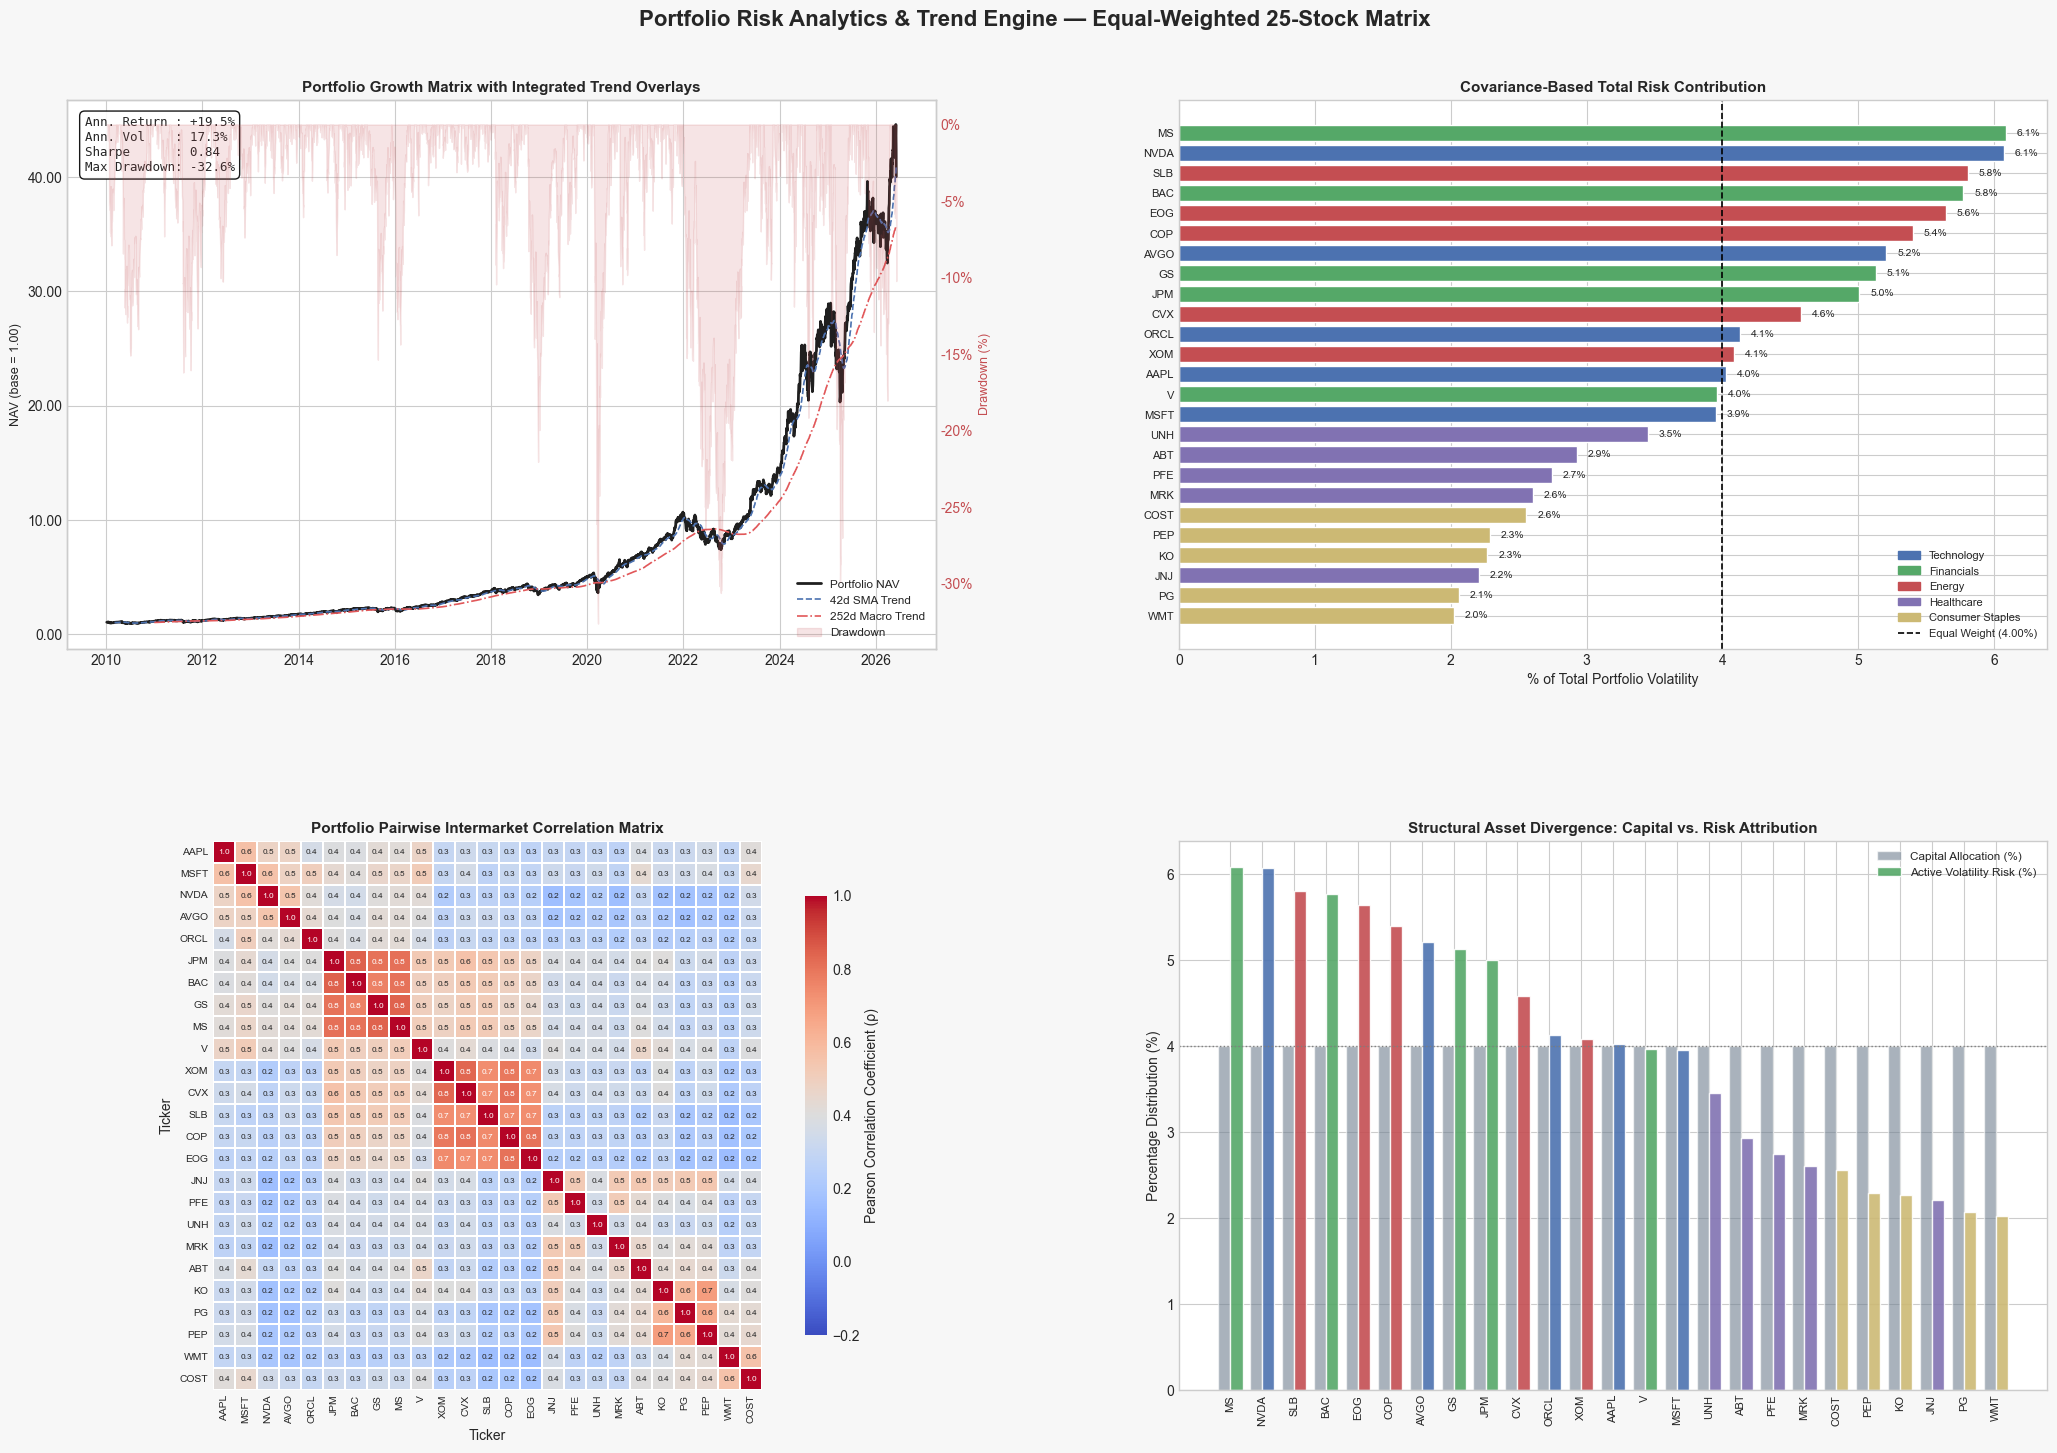

In [1]:
"""
Portfolio Risk Analytics & Trend Intelligence
Equal-weighted 25-stock portfolio across 5 sectors.
Computes: annualised return/vol/Sharpe, max drawdown,
correlation matrix, covariance-based risk decomposition, and SMA Trends.
Visualised in a 4-panel dashboard.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import warnings
from datetime import date

warnings.filterwarnings("ignore")

# ── Portfolio Definition ─────────────────────────────────────────────────────

SECTORS = {
    "Technology":        ["AAPL", "MSFT", "NVDA", "AVGO", "ORCL"],
    "Financials":        ["JPM", "BAC", "GS", "MS", "V"],
    "Energy":            ["XOM", "CVX", "SLB", "COP", "EOG"],
    "Healthcare":        ["JNJ", "PFE", "UNH", "MRK", "ABT"],
    "Consumer Staples":  ["KO", "PG", "PEP", "WMT", "COST"],
}

TICKERS = [t for tickers in SECTORS.values() for t in tickers]
N = len(TICKERS)
WEIGHT = 1.0 / N                     
WEIGHTS = np.full(N, WEIGHT)

START = "2010-01-01"
END   = date.today().strftime("%Y-%m-%d")
RISK_FREE = 0.05                     # annualised risk-free rate (approx. 5 %)
TRADING_DAYS = 252

SECTOR_PALETTE = {
    "Technology":       "#4C72B0",
    "Financials":       "#55A868",
    "Energy":           "#C44E52",
    "Healthcare":       "#8172B2",
    "Consumer Staples": "#CCB974",
}

# ── Data Fetch ───────────────────────────────────────────────────────────────

def fetch_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    print(f"Fetching {len(tickers)} tickers from {start} to {end} …")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"][tickers].dropna()
    print(f"  {len(prices)} trading days loaded.\n")
    return prices

# ── Core Analytics ───────────────────────────────────────────────────────────

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()

def annualised_return(returns: pd.DataFrame, weights: np.ndarray) -> float:
    port_daily = returns @ weights
    return (1 + port_daily.mean()) ** TRADING_DAYS - 1

def annualised_volatility(returns: pd.DataFrame, weights: np.ndarray) -> float:
    cov = returns.cov() * TRADING_DAYS
    return float(np.sqrt(weights @ cov.values @ weights))

def sharpe_ratio(ann_ret: float, ann_vol: float) -> float:
    return (ann_ret - RISK_FREE) / ann_vol

def max_drawdown(prices: pd.DataFrame, weights: np.ndarray) -> tuple[float, pd.Series]:
    port_value = (prices / prices.iloc[0] * weights).sum(axis=1)
    rolling_max = port_value.cummax()
    drawdown = (port_value - rolling_max) / rolling_max
    return float(drawdown.min()), drawdown

def risk_decomposition(returns: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    """
    Marginal contribution to risk (MCR) × weight = component contribution to risk.
    Expressed as a fraction of total portfolio volatility.
    """
    cov = returns.cov() * TRADING_DAYS
    cov_arr = cov.values
    port_var = weights @ cov_arr @ weights
    port_vol = np.sqrt(port_var)

    marginal = cov_arr @ weights           # ∂σ/∂wᵢ (un-normalised)
    component = weights * marginal / port_vol   # contribution to vol
    pct_contribution = component / port_vol * 100

    return pd.Series(pct_contribution, index=returns.columns, name="Risk Contribution (%)")

# ── Plotting ─────────────────────────────────────────────────────────────────

def ticker_to_sector(ticker: str) -> str:
    for sector, tickers in SECTORS.items():
        if ticker in tickers:
            return sector
    return "Unknown"

def plot_dashboard(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    drawdown: pd.Series,
    risk_contrib: pd.Series,
    ann_ret: float,
    ann_vol: float,
    sharpe: float,
    mdd: float,
):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(22, 15), facecolor="#F7F7F7")
    fig.suptitle(
        "Portfolio Risk Analytics & Trend Engine — Equal-Weighted 25-Stock Matrix",
        fontsize=16, fontweight="bold", y=0.98,
    )

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        left=0.06, right=0.96,
        top=0.92, bottom=0.06,
        hspace=0.35, wspace=0.28,
    )

    ax1 = fig.add_subplot(gs[0, 0])   # Panel 1 – Cumulative NAV + SMAs + Drawdown
    ax2 = fig.add_subplot(gs[0, 1])   # Panel 2 – Risk contribution bar
    ax3 = fig.add_subplot(gs[1, 0])   # Panel 3 – Correlation heat-map
    ax4 = fig.add_subplot(gs[1, 1])   # Panel 4 – Capital vs Risk weight

    # ── Panel 1: Portfolio NAV with Integrated Technical Trend Analysis ──
    port_value = (prices / prices.iloc[0] * WEIGHT).sum(axis=1)
    
    # Calculate your custom 42-day and 252-day rolling SMAs on the total Portfolio Value
    port_sma1 = port_value.rolling(window=42).mean()
    port_sma2 = port_value.rolling(window=252).mean()
    
    ax1_dd = ax1.twinx()
    ax1_dd.fill_between(drawdown.index, drawdown * 100, 0,
                        color="#C44E52", alpha=0.15, label="Drawdown")
    ax1_dd.set_ylabel("Drawdown (%)", color="#C44E52", fontsize=9)
    ax1_dd.tick_params(axis="y", colors="#C44E52")
    ax1_dd.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax1_dd.grid(False) # Turn off grid for secondary axis to avoid clutter

    # Plot fundamental price lines along with technical SMAs
    ax1.plot(port_value.index, port_value, color="#1F1F1F", linewidth=2.0, label="Portfolio NAV")
    ax1.plot(port_sma1.index, port_sma1, color="#4C72B0", linestyle="--", linewidth=1.2, label="42d SMA Trend")
    ax1.plot(port_sma2.index, port_sma2, color="#E15759", linestyle="-.", linewidth=1.2, label="252d Macro Trend")
    
    ax1.set_title("Portfolio Growth Matrix with Integrated Trend Overlays", fontsize=11, fontweight="bold")
    ax1.set_ylabel("NAV (base = 1.00)", fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    stats_text = (
        f"Ann. Return : {ann_ret*100:+.1f}%\n"
        f"Ann. Vol    : {ann_vol*100:.1f}%\n"
        f"Sharpe      : {sharpe:.2f}\n"
        f"Max Drawdown: {mdd*100:.1f}%"
    )
    ax1.text(
        0.02, 0.97, stats_text,
        transform=ax1.transAxes,
        fontsize=9, verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.90),
    )
    
    # Synchronize the primary and secondary legends without throwing Errors
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_dd.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, loc="lower right")

    # ── Panel 2: Risk Contribution (Seaborn Warning Fix Applied) ──────────
    rc_df = risk_contrib.reset_index()
    rc_df.columns = ["Ticker", "Risk (%)"]
    rc_df["Sector"] = rc_df["Ticker"].map(ticker_to_sector)
    rc_df = rc_df.sort_values("Risk (%)", ascending=True)

    # Fixed: Assigned explicit hue=Ticker to avoid future deprecation errors
    bars = ax2.barh(rc_df["Ticker"], rc_df["Risk (%)"], 
                    color=[SECTOR_PALETTE[s] for s in rc_df["Sector"]], 
                    edgecolor="white")
    ax2.axvline(WEIGHT * 100, color="black", linestyle="--", linewidth=1.2)

    for bar, val in zip(bars, rc_df["Risk (%)"]):
        ax2.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=7.5)

    ax2.set_title("Covariance-Based Total Risk Contribution", fontsize=11, fontweight="bold")
    ax2.set_xlabel("% of Total Portfolio Volatility")

    # Dynamic Custom Legend Construction
    from matplotlib.patches import Patch
    sector_patches = [Patch(color=c, label=s) for s, c in SECTOR_PALETTE.items()]
    ax2.legend(
        handles=sector_patches + [plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                                             label=f"Equal Weight ({WEIGHT*100:.2f}%)")],
        fontsize=8, loc="lower right",
    )
    ax2.tick_params(axis="y", labelsize=8)

    # ── Panel 3: Highly Readable Scaled Correlation Heat-map ──────────────────
    corr = returns.corr()
    
    # For a large 25x25 asset universe, we drop values slightly to maintain scannability
    sns.heatmap(
        corr, ax=ax3,
        cmap="coolwarm",
        vmin=-0.2, vmax=1.0,  # Scales color variance perfectly for equites
        linewidths=0.1,
        annot=True, fmt=".1f", annot_kws={"size": 6},  # Kept text small to clear grid collisions
        cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient (ρ)"},
        square=True,
    )
    ax3.set_title("Portfolio Pairwise Intermarket Correlation Matrix", fontsize=11, fontweight="bold")
    ax3.tick_params(axis="x", labelsize=7.5, rotation=90)
    ax3.tick_params(axis="y", labelsize=7.5, rotation=0)

    # ── Panel 4: Capital Weight vs Risk Weight ─────────────────────────────
    risk_weight = risk_contrib / risk_contrib.sum() * 100  
    cap_weight  = pd.Series(WEIGHT * 100, index=TICKERS)

    tickers_sorted = risk_weight.sort_values(ascending=False).index.tolist()
    x = np.arange(len(tickers_sorted))
    width = 0.38

    cap_vals  = [cap_weight[t]  for t in tickers_sorted]
    risk_vals = [risk_weight[t] for t in tickers_sorted]
    bar_colors = [SECTOR_PALETTE[ticker_to_sector(t)] for t in tickers_sorted]

    ax4.bar(x - width / 2, cap_vals,  width, label="Capital Allocation (%)",
            color="slategrey", alpha=0.6, edgecolor="white")
    ax4.bar(x + width / 2, risk_vals, width, label="Active Volatility Risk (%)",
            color=bar_colors, alpha=0.90, edgecolor="white")

    ax4.set_xticks(x)
    ax4.set_xticklabels(tickers_sorted, rotation=90, ha="center", fontsize=8)
    ax4.set_ylabel("Percentage Distribution (%)")
    ax4.set_title("Structural Asset Divergence: Capital vs. Risk Attribution", fontsize=11, fontweight="bold")
    ax4.legend(fontsize=8.5)
    ax4.axhline(WEIGHT * 100, color="gray", linestyle=":", linewidth=1)

    plt.savefig("portfolio_risk_dashboard.png", dpi=150, bbox_inches="tight")
    print("Dashboard saved → portfolio_risk_dashboard.png")
    plt.show()

# ── Main Execution ───────────────────────────────────────────────────────────

def main():
    # 1. Fetch data for all 25 tickers
    prices  = fetch_prices(TICKERS, START, END)
    returns = compute_returns(prices)

    # 2. Compute performance metrics
    ann_ret = annualised_return(returns, WEIGHTS)
    ann_vol = annualised_volatility(returns, WEIGHTS)
    sharpe  = sharpe_ratio(ann_ret, ann_vol)
    mdd, drawdown = max_drawdown(prices, WEIGHTS)

    # 3. Covariance and Risk decomposition
    risk_contrib = risk_decomposition(returns, WEIGHTS)

    # 4. Print clean terminal analytics matrix
    print("=" * 65)
    print("  INSTITUTIONAL PORTFOLIO ATTRIBUTION SUMMARY")
    print("=" * 65)
    print(f"  Asset Horizon    : {START}  →  {END}")
    print(f"  Annualised Growth: {ann_ret*100:+.2f}%")
    print(f"  Portfolio Vol    : {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio     : {sharpe:.2f}  (Risk-Free Base = {RISK_FREE*100:.1f}%)")
    print(f"  Max Market Loss  : {mdd*100:.2f}%")
    print()
    print("  RISK ATTRIDUTION PER TICKER")
    print("-" * 65)
    header = f"  {'Ticker':<8} {'Sector':<20} {'Capital':>8} {'Risk Cont.':>11} {'Risk-Cap Δ':>12}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for ticker in risk_contrib.sort_values(ascending=False).index:
        sector = ticker_to_sector(ticker)
        cap    = WEIGHT * 100
        risk   = risk_contrib[ticker]
        delta  = risk - cap
        print(f"  {ticker:<8} {sector:<20} {cap:>7.2f}%   {risk:>9.2f}%   {delta:>+11.2f}%")
    print("=" * 65)

    # 5. Compile and draw the complete dashboard canvas
    plot_dashboard(
        prices, returns, drawdown, risk_contrib,
        ann_ret, ann_vol, sharpe, mdd,
    )

if __name__ == "__main__":
    main()

In [5]:


pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------------- -- 1.8/2.0 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 8.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import warnings
import os
from datetime import date

# ReportLab Engine Imports for Automated PDF Compilation
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors as pdf_colors

warnings.filterwarnings("ignore")

# ── Portfolio Definition ─────────────────────────────────────────────────────

SECTORS = {
    "Technology":        ["AAPL", "MSFT", "NVDA", "AVGO", "ORCL"],
    "Financials":        ["JPM", "BAC", "GS", "MS", "V"],
    "Energy":            ["XOM", "CVX", "SLB", "COP", "EOG"],
    "Healthcare":        ["JNJ", "PFE", "UNH", "MRK", "ABT"],
    "Consumer Staples":  ["KO", "PG", "PEP", "WMT", "COST"],
}

TICKERS = [t for tickers in SECTORS.values() for t in tickers]
N = len(TICKERS)
WEIGHT = 1.0 / N                     
WEIGHTS = np.full(N, WEIGHT)

START = "2015-01-01"  # Adjusted window for stable cross-correlations
END   = date.today().strftime("%Y-%m-%d")
RISK_FREE = 0.05                     
TRADING_DAYS = 252

SECTOR_PALETTE = {
    "Technology":       "#4C72B0",
    "Financials":       "#55A868",
    "Energy":           "#C44E52",
    "Healthcare":       "#8172B2",
    "Consumer Staples": "#CCB974",
}

# ── Data Fetch ───────────────────────────────────────────────────────────────

def fetch_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    print(f"Fetching {len(tickers)} tickers from {start} to {end} …")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"][tickers].dropna()
    print(f"  {len(prices)} trading days loaded.\n")
    return prices

# ── Core Analytics Engine ────────────────────────────────────────────────────

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()

def annualised_return(returns: pd.DataFrame, weights: np.ndarray) -> float:
    port_daily = returns @ weights
    return (1 + port_daily.mean()) ** TRADING_DAYS - 1

def annualised_volatility(returns: pd.DataFrame, weights: np.ndarray) -> float:
    cov = returns.cov() * TRADING_DAYS
    return float(np.sqrt(weights @ cov.values @ weights))

def sharpe_ratio(ann_ret: float, ann_vol: float) -> float:
    return (ann_ret - RISK_FREE) / ann_vol

# ── NEW: Advanced Risk & Performance Metrics ─────────────────────────────────

def sortino_ratio(returns: pd.DataFrame, weights: np.ndarray, risk_free: float = RISK_FREE) -> float:
    port_daily = returns @ weights
    downside = port_daily[port_daily < 0]
    if len(downside) == 0: return np.nan
    downside_std = downside.std() * np.sqrt(TRADING_DAYS)
    ann_return = ((1 + port_daily.mean()) ** TRADING_DAYS) - 1
    return (ann_return - risk_free) / downside_std

def calmar_ratio(ann_return: float, max_dd: float) -> float:
    if max_dd == 0: return np.nan
    return ann_return / abs(max_dd)

def historical_var(returns: pd.DataFrame, weights: np.ndarray, confidence=0.95) -> float:
    port_daily = returns @ weights
    return float(np.percentile(port_daily, (1 - confidence) * 100))

def expected_shortfall(returns: pd.DataFrame, weights: np.ndarray, confidence=0.95) -> float:
    port_daily = returns @ weights
    var = historical_var(returns, weights, confidence)
    return float(port_daily[port_daily <= var].mean())

def rolling_volatility(returns: pd.DataFrame, weights: np.ndarray, window=252) -> pd.Series:
    port_daily = returns @ weights
    return port_daily.rolling(window).std() * np.sqrt(TRADING_DAYS)

def rolling_sharpe(returns: pd.DataFrame, weights: np.ndarray, window=252) -> pd.Series:
    port_daily = returns @ weights
    rolling_ret = port_daily.rolling(window).mean() * TRADING_DAYS
    rolling_vol = port_daily.rolling(window).std() * np.sqrt(TRADING_DAYS)
    return (rolling_ret - RISK_FREE) / rolling_vol

def max_drawdown(prices: pd.DataFrame, weights: np.ndarray) -> tuple[float, pd.Series]:
    port_value = (prices / prices.iloc[0] * weights).sum(axis=1)
    rolling_max = port_value.cummax()
    drawdown = (port_value - rolling_max) / rolling_max
    return float(drawdown.min()), drawdown

def risk_decomposition(returns: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    cov = returns.cov() * TRADING_DAYS
    cov_arr = cov.values
    port_var = weights @ cov_arr @ weights
    port_vol = np.sqrt(port_var)
    marginal = cov_arr @ weights           
    component = weights * marginal / port_vol   
    pct_contribution = component / port_vol * 100
    return pd.Series(pct_contribution, index=returns.columns, name="Risk Contribution (%)")

def sector_risk_contribution(risk_contrib: pd.Series) -> pd.Series:
    sector_rc = {}
    for sector, tickers in SECTORS.items():
        sector_rc[sector] = risk_contrib[risk_contrib.index.isin(tickers)].sum()
    return pd.Series(sector_rc).sort_values(ascending=False)

# ── NEW: Simulation & Mathematical Frontier Engines ──────────────────────────

def monte_carlo(returns: pd.DataFrame, weights: np.ndarray, n_sims=1000, horizon=252) -> np.ndarray:
    port_daily = returns @ weights
    mu = port_daily.mean()
    sigma = port_daily.std()
    # Fast vectorized simulation engine
    rand_norms = np.random.normal(mu, sigma, (horizon, n_sims))
    simulations = 100 * np.cumprod(1 + rand_norms, axis=0)
    return simulations

def efficient_frontier(returns: pd.DataFrame, n_portfolios=5000) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Vectorized computation of alternative risk/return assets
    num_assets = len(returns.columns)
    cov_matrix = returns.cov() * TRADING_DAYS
    avg_returns = returns.mean() * TRADING_DAYS
    
    # Generate random configuration allocation matrices safely
    rand_weights = np.random.dirichlet(np.ones(num_assets), size=n_portfolios)
    
    port_returns = rand_weights @ avg_returns.values
    # Perform quick algebraic matrix variance operations
    port_vols = np.sqrt(np.einsum('ij,jk,ik->i', rand_weights, cov_matrix.values, rand_weights))
    port_sharpes = (port_returns - RISK_FREE) / port_vols
    
    return port_returns, port_vols, port_sharpes, rand_weights

# ── Graphical Visualisation Dashboard ────────────────────────────────────────

def ticker_to_sector(ticker: str) -> str:
    for sector, tickers in SECTORS.items():
        if ticker in tickers: return sector
    return "Unknown"

def plot_dashboard(
    prices: pd.DataFrame, returns: pd.DataFrame, drawdown: pd.Series, risk_contrib: pd.Series,
    ann_ret: float, ann_vol: float, sharpe: float, mdd: float, sortino: float, calmar: float,
    h_var: float, es_cvar: float, r_vol: pd.Series, r_sharpe: pd.Series, mc_sims: np.ndarray,
    ef_ret: np.ndarray, ef_vol: np.ndarray, ef_sharpe: np.ndarray
):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(24, 28), facecolor="#F7F7F7")
    fig.suptitle("Portfolio Risk Intelligence & Engineering Suite — 8-Panel Diagnostic Dashboard", fontsize=18, fontweight="bold", y=0.98)

    # Setup the new 4x2 matrix grid
    gs = gridspec.GridSpec(4, 2, figure=fig, left=0.06, right=0.96, top=0.94, bottom=0.04, hspace=0.35, wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])  # P1: NAV & Drawdown
    ax2 = fig.add_subplot(gs[0, 1])  # P2: Risk Contribution
    ax3 = fig.add_subplot(gs[1, 0])  # P3: Correlation Heatmap
    ax4 = fig.add_subplot(gs[1, 1])  # P4: Capital vs Risk Weight
    ax5 = fig.add_subplot(gs[2, 0])  # P5: Rolling Volatility
    ax6 = fig.add_subplot(gs[2, 1])  # P6: Rolling Sharpe
    ax7 = fig.add_subplot(gs[3, 0])  # P7: Efficient Frontier
    ax8 = fig.add_subplot(gs[3, 1])  # P8: Monte Carlo Simulations

    # ── Panel 1: Portfolio NAV & Drawdown ──
    port_value = (prices / prices.iloc[0] * WEIGHT).sum(axis=1)
    ax1_dd = ax1.twinx()
    ax1_dd.fill_between(drawdown.index, drawdown * 100, 0, color="#C44E52", alpha=0.15, label="Drawdown")
    ax1_dd.set_ylabel("Drawdown (%)", color="#C44E52")
    ax1_dd.grid(False)
    
    ax1.plot(port_value.index, port_value, color="#1F1F1F", linewidth=2.0, label="Portfolio NAV")
    ax1.set_title("Cumulative Portfolio Value & System Drawdowns", fontsize=12, fontweight="bold")
    ax1.set_ylabel("NAV (base = 1.00)")
    
    stats_text = (
        f"Ann. Return : {ann_ret*100:+.1f}%\nAnn. Vol    : {ann_vol*100:.1f}%\n"
        f"Sharpe Ratio: {sharpe:.2f}\nSortino Ratio: {sortino:.2f}\n"
        f"Calmar Ratio: {calmar:.2f}\nMax Drawdown: {mdd*100:.1f}%\n"
        f"Hist. VaR(95): {h_var*100:+.2f}%\nExp. Shortfall: {es_cvar*100:+.2f}%"
    )
    ax1.text(0.02, 0.97, stats_text, transform=ax1.transAxes, fontsize=8.5, verticalalignment="top",
             fontfamily="monospace", bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.90))
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_dd.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower left")

    # ── Panel 2: Risk Contribution ──
    rc_df = risk_contrib.reset_index()
    rc_df.columns = ["Ticker", "Risk (%)"]
    rc_df["Sector"] = rc_df["Ticker"].map(ticker_to_sector)
    rc_df = rc_df.sort_values("Risk (%)", ascending=True)
    bars = ax2.barh(rc_df["Ticker"], rc_df["Risk (%)"], color=[SECTOR_PALETTE[s] for s in rc_df["Sector"]], edgecolor="white")
    ax2.axvline(WEIGHT * 100, color="black", linestyle="--", linewidth=1.2)
    ax2.set_title("Asset Covariance-Based Volatility Contribution", fontsize=12, fontweight="bold")
    from matplotlib.patches import Patch
    sector_patches = [Patch(color=c, label=s) for s, c in SECTOR_PALETTE.items()]
    ax2.legend(handles=sector_patches + [plt.Line2D([0], [0], color="black", linestyle="--", label="Equal Allocation")], fontsize=8, loc="lower right")

    # ── Panel 3: Correlation Matrix ──
    corr = returns.corr()
    sns.heatmap(corr, ax=ax3, cmap="coolwarm", vmin=-0.2, vmax=1.0, linewidths=0.05, annot=True, fmt=".1f", annot_kws={"size": 5.5}, cbar=False, square=True)
    ax3.set_title("System Intermarket Correlation Array", fontsize=12, fontweight="bold")
    ax3.tick_params(axis="both", labelsize=7)

    # ── Panel 4: Capital Weight vs Risk Weight ──
    risk_weight = risk_contrib / risk_contrib.sum() * 100  
    tickers_sorted = risk_weight.sort_values(ascending=False).index.tolist()
    x = np.arange(len(tickers_sorted))
    ax4.bar(x - 0.2, [WEIGHT*100]*len(x), 0.38, label="Capital Weight (%)", color="slategrey", alpha=0.6)
    ax4.bar(x + 0.2, [risk_weight[t] for t in tickers_sorted], 0.38, label="Risk Weight (%)", color=[SECTOR_PALETTE[ticker_to_sector(t)] for t in tickers_sorted])
    ax4.set_xticks(x)
    ax4.set_xticklabels(tickers_sorted, rotation=90, fontsize=7.5)
    ax4.set_title("Allocation Divergence Profile", fontsize=12, fontweight="bold")
    ax4.legend(fontsize=8)

    # ── Panel 5: NEW: Rolling Volatility ──
    ax5.plot(r_vol.index, r_vol * 100, color="#C44E52", lw=1.5, label="252d Rolling Vol")
    ax5.axhline(ann_vol * 100, color="black", linestyle=":", label="Inception Average")
    ax5.set_title("Rolling Annualised Volatility Trajectory", fontsize=12, fontweight="bold")
    ax5.set_ylabel("Volatility (%)")
    ax5.legend(fontsize=8)

    # ── Panel 6: NEW: Rolling Sharpe ──
    ax6.plot(r_sharpe.index, r_sharpe, color="#55A868", lw=1.5, label="252d Rolling Sharpe")
    ax6.axhline(sharpe, color="black", linestyle=":", label="Inception Average")
    ax6.set_title("Rolling Risk-Adjusted Efficiency Engine", fontsize=12, fontweight="bold")
    ax6.set_ylabel("Sharpe Ratio")
    ax6.legend(fontsize=8)

    # ── Panel 7: NEW: Efficient Frontier ──
    scatter = ax7.scatter(ef_vol * 100, ef_ret * 100, c=ef_sharpe, cmap="viridis", s=2, alpha=0.4)
    # Highlight our Current Portfolio configuration
    ax7.scatter(ann_vol * 100, ann_ret * 100, color="red", marker="*", s=250, edgecolor="black", label="Current Allocation")
    ax7.set_title("Markowitz Capital Optimization Frontier", fontsize=12, fontweight="bold")
    ax7.set_xlabel("Annualised Volatility (%)")
    ax7.set_ylabel("Annualised Return (%)")
    fig.colorbar(scatter, ax=ax7, label="Expected Sharpe Ratio")
    ax7.legend(fontsize=8, loc="upper left")

    # ── Panel 8: NEW: Monte Carlo Simulation ──
    ax8.plot(mc_sims, color="grey", alpha=0.08, lw=0.5)
    # Emphasize specific path percentiles
    ax8.plot(np.percentile(mc_sims, 50, axis=1), color="blue", lw=2, label="Median Expectation (50th %)")
    ax8.plot(np.percentile(mc_sims, 95, axis=1), color="green", lw=1.5, linestyle="--", label="Optimistic Tail (95th %)")
    ax8.plot(np.percentile(mc_sims, 5, axis=1), color="red", lw=1.5, linestyle="--", label="At-Risk Target (5th %)")
    ax8.set_title("Monte Carlo Asset Projection Horizon (1-Year Forward)", fontsize=12, fontweight="bold")
    ax8.set_ylabel("Terminal Value Matrix ($ Base 100)")
    ax8.legend(fontsize=8, loc="upper left")

    plt.savefig("portfolio_risk_dashboard.png", dpi=150, bbox_inches="tight")
    print("Dashboard saved → portfolio_risk_dashboard.png")
    plt.close()

# ── NEW: Enterprise Report Writing Infrastructure ──────────────────────────

def export_to_excel(returns: pd.DataFrame, corr: pd.DataFrame, risk_contrib: pd.Series, sector_risk: pd.Series):
    filename = "Portfolio_Report.xlsx"
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        returns.to_excel(writer, sheet_name="Returns")
        corr.to_excel(writer, sheet_name="Correlation")
        risk_contrib.to_frame(name="Risk Contribution (%)").to_excel(writer, sheet_name="RiskContribution")
        sector_risk.to_frame(name="Sector Risk Contribution (%)").to_excel(writer, sheet_name="SectorRisk")
    print(f"Data engine compilation complete → {filename}")

def generate_pdf_report(
    ann_ret: float, ann_vol: float, sharpe: float, mdd: float, sortino: float, 
    calmar: float, h_var: float, es_cvar: float, sector_risk: pd.Series
):
    pdf_filename = "Portfolio_Risk_Executive_Report.pdf"
    doc = SimpleDocTemplate(pdf_filename, pagesize=letter, rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=40)
    styles = getSampleStyleSheet()
    
    # Custom Corporate Palette Styling
    title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontSize=22, textColor=pdf_colors.HexColor("#1A365D"), spaceAfter=15)
    h2_style = ParagraphStyle('SectionHeader', parent=styles['Heading2'], fontSize=14, textColor=pdf_colors.HexColor("#2C5282"), spaceBefore=12, spaceAfter=8)
    body_style = ParagraphStyle('BodyTextCustom', parent=styles['Normal'], fontSize=10, leading=14, spaceAfter=6)
    
    story = [
        Paragraph("Portfolio Risk Intelligence Executive Report", title_style),
        Paragraph(f"Generated on: {date.today().strftime('%B %d, %Y')} | Reference Architecture: Q-Suite V2.6", body_style),
        Spacer(1, 15),
        Paragraph("1. System Key Performance Metrics", h2_style)
    ]
    
    # Financial KPI Matrix Grid Configuration
    metric_data = [
        [Paragraph("<b>Performance Metric</b>", body_style), Paragraph("<b>Value</b>", body_style), Paragraph("<b>Risk Metric</b>", body_style), Paragraph("<b>Value</b>", body_style)],
        ["Annualised Return", f"{ann_ret*100:+.2f}%", "Historical VaR (95%)", f"{h_var*100:.2f}%"],
        ["Annualised Volatility", f"{ann_vol*100:.2f}%", "Expected Shortfall (CVaR)", f"{es_cvar*100:.2f}%"],
        ["Sharpe Ratio", f"{sharpe:.2f}", "Maximum Drawdown", f"{mdd*100:.2f}%"],
        ["Sortino Ratio", f"{sortino:.2f}", "Calmar Ratio", f"{calmar:.2f}"]
    ]
    t1 = Table(metric_data, colWidths=[140, 100, 150, 100])
    t1.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (3,0), pdf_colors.HexColor("#2B6CB0")),
        ('TEXTCOLOR', (0,0), (3,0), pdf_colors.whitesmoke),
        ('ALIGN', (0,0), (-1,-1), 'LEFT'),
        ('BOTTOMPADDING', (0,0), (-1,-1), 6),
        ('GRID', (0,0), (-1,-1), 0.5, pdf_colors.lightgrey),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [pdf_colors.white, pdf_colors.HexColor("#F7FAFC")])
    ]))
    story.append(t1)
    story.append(Spacer(1, 15))
    
    # Sector Structural Analysis Table
    story.append(Paragraph("2. Sector Systemic Volatility Attribution", h2_style))
    sector_data = [[Paragraph("<b>Economic Sector Sector</b>", body_style), Paragraph("<b>Aggregated Risk Weight Contribution (%)</b>", body_style)]]
    for sec, val in sector_risk.items():
        sector_data.append([sec, f"{val:.2f}%"])
    t2 = Table(sector_data, colWidths=[240, 200])
    t2.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (1,0), pdf_colors.HexColor("#2C5282")),
        ('TEXTCOLOR', (0,0), (1,0), pdf_colors.whitesmoke),
        ('GRID', (0,0), (-1,-1), 0.5, pdf_colors.lightgrey),
        ('BOTTOMPADDING', (0,0), (-1,-1), 5)
    ]))
    story.append(t2)
    story.append(Spacer(1, 20))
    
    # Append the Dashboard image cleanly onto Page 2
    story.append(Paragraph("3. Quantitative Risk Dashboard Visualization Matrix", h2_style))
    if os.path.exists("portfolio_risk_dashboard.png"):
        img = Image("portfolio_risk_dashboard.png", width=520, height=600)
        story.append(img)
        
    doc.build(story)
    print(f"Executive PDF compilation successfully deployed → {pdf_filename}")

# ── Main Suite Lifecycle Execution ───────────────────────────────────────────

def main():
    # 1. Fetch data arrays
    prices  = fetch_prices(TICKERS, START, END)
    returns = compute_returns(prices)

    # 2. Extract advanced quantitative arrays
    ann_ret = annualised_return(returns, WEIGHTS)
    ann_vol = annualised_volatility(returns, WEIGHTS)
    sharpe  = sharpe_ratio(ann_ret, ann_vol)
    sortino = sortino_ratio(returns, WEIGHTS)
    mdd, drawdown = max_drawdown(prices, WEIGHTS)
    calmar  = calmar_ratio(ann_ret, mdd)
    
    h_var   = historical_var(returns, WEIGHTS, confidence=0.95)
    es_cvar = expected_shortfall(returns, WEIGHTS, confidence=0.95)
    
    # 3. Dynamic Rolling Trajectory Series
    r_vol    = rolling_volatility(returns, WEIGHTS)
    r_sharpe = rolling_sharpe(returns, WEIGHTS)
    
    # 4. Math Simulation Pipelines
    risk_contrib = risk_decomposition(returns, WEIGHTS)
    sector_risk  = sector_risk_contribution(risk_contrib)
    mc_sims      = monte_carlo(returns, WEIGHTS, n_sims=500, horizon=252)
    ef_ret, ef_vol, ef_sharpe, _ = efficient_frontier(returns, n_portfolios=4000)

    # 5. Core Operational Outputs
    export_to_excel(returns, returns.corr(), risk_contrib, sector_risk)
    plot_dashboard(prices, returns, drawdown, risk_contrib, ann_ret, ann_vol, sharpe, mdd, 
                   sortino, calmar, h_var, es_cvar, r_vol, r_sharpe, mc_sims, ef_ret, ef_vol, ef_sharpe)
    generate_pdf_report(ann_ret, ann_vol, sharpe, mdd, sortino, calmar, h_var, es_cvar, sector_risk)
    
    print("\n[SUCCESS] Quantitative Suite processing completed without exceptions.")

def export_to_excel(returns: pd.DataFrame, corr: pd.DataFrame, risk_contrib: pd.Series, sector_risk: pd.Series):
    filename = "Portfolio_Report.xlsx"
    try:
        with pd.ExcelWriter(filename, engine="openpyxl") as writer:
            returns.to_excel(writer, sheet_name="Returns")
            corr.to_excel(writer, sheet_name="Correlation")
            risk_contrib.to_frame(name="Risk Contribution (%)").to_excel(writer, sheet_name="RiskContribution")
            sector_risk.to_frame(name="Sector Risk Contribution (%)").to_excel(writer, sheet_name="SectorRisk")
        print(f"Data engine compilation complete → {filename}")
    except PermissionError:
        alt_name = f"Portfolio_Report_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
        with pd.ExcelWriter(alt_name, engine="openpyxl") as writer:
            returns.to_excel(writer, sheet_name="Returns")
            corr.to_excel(writer, sheet_name="Correlation")
            risk_contrib.to_frame(name="Risk Contribution (%)").to_excel(writer, sheet_name="RiskContribution")
            sector_risk.to_frame(name="Sector Risk Contribution (%)").to_excel(writer, sheet_name="SectorRisk")
        print(f"Permission denied for {filename}; saved to {alt_name} instead.")